# Preprocessing Analysis Report

Covers two DuckDB tables: `opf_samples` and `powergraph_files`, with paper-ready tables/figures.

In [1]:

import duckdb, pandas as pd, matplotlib.pyplot as plt
from pathlib import Path
%matplotlib inline
DB='../data/processed/opfdata.duckdb'
OUT=Path('.')
OUT.mkdir(exist_ok=True)
con=duckdb.connect(DB)


## 1) OPFData table overview (`opf_samples`)

In [2]:

con.execute('SELECT COUNT(*) AS total_rows FROM opf_samples').df()


,total_rows
0,60000


In [3]:

case_df = con.execute('''
SELECT case_name, COUNT(*) AS samples
FROM opf_samples
GROUP BY case_name
ORDER BY samples DESC
''').df()
case_df


,case_name,samples
0,dataset_release_1__pglib_opf_case14_ieee_0_ext...,15000
1,dataset_release_1__pglib_opf_case118_ieee_0_ex...,15000
2,dataset_release_1__pglib_opf_case30_ieee_0_ext...,15000
3,dataset_release_1__pglib_opf_case57_ieee_0_ext...,15000


In [4]:

stats_df = con.execute('''
SELECT 
  MIN(n_nodes) AS min_nodes, MAX(n_nodes) AS max_nodes, AVG(n_nodes) AS avg_nodes,
  MIN(n_edges) AS min_edges, MAX(n_edges) AS max_edges, AVG(n_edges) AS avg_edges,
  MIN(objective) AS min_obj, MAX(objective) AS max_obj, AVG(objective) AS avg_obj
FROM opf_samples
''').df()
stats_df


,min_nodes,max_nodes,avg_nodes,min_edges,max_edges,avg_edges,min_obj,max_obj,avg_obj
0,31,285,121.0,12,12,12.0,1820.451532,104556.352997,36267.015415


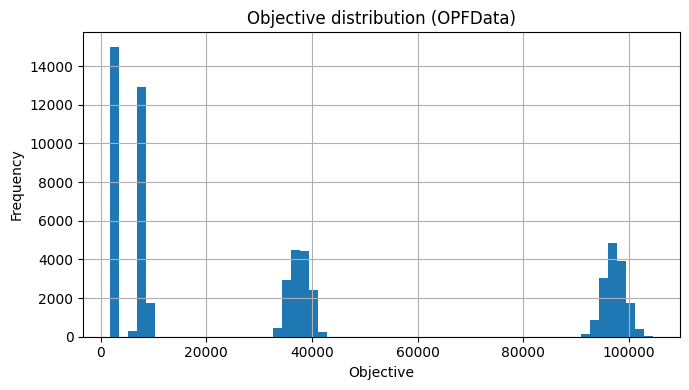

In [5]:

obj = con.execute('SELECT objective FROM opf_samples WHERE objective IS NOT NULL').df()['objective']
plt.figure(figsize=(7,4))
obj.hist(bins=60)
plt.title('Objective distribution (OPFData)')
plt.xlabel('Objective')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig(OUT/'fig_objective_hist.png', dpi=200)
plt.show()


## 2) PowerGraph metadata table (`powergraph_files`)

In [6]:

con.execute('SELECT COUNT(*) AS total_rows FROM powergraph_files').df()


,total_rows
0,32


In [7]:

pg_df = con.execute('''
SELECT filename, relpath, ROUND(size_mb,3) AS size_mb, n_keys
FROM powergraph_files
ORDER BY filename
''').df()
pg_df.head(40)


,filename,relpath,size_mb,n_keys
0,ieee118__ieee118__raw__Bf.mat.json,powergraph/dataset_cascades_extracted/dataset_...,373.527,2
1,ieee118__ieee118__raw__Ef.mat.json,powergraph/dataset_cascades_extracted/dataset_...,738.031,2
2,ieee118__ieee118__raw__Ef_nc.mat.json,powergraph/dataset_cascades_extracted/dataset_...,738.031,2
3,ieee118__ieee118__raw__blist.mat.json,powergraph/dataset_cascades_extracted/dataset_...,0.005,1
4,ieee118__ieee118__raw__exp.mat.json,powergraph/dataset_cascades_extracted/dataset_...,48.331,2
5,ieee118__ieee118__raw__of_bi.mat.json,powergraph/dataset_cascades_extracted/dataset_...,43.611,2
6,ieee118__ieee118__raw__of_mc.mat.json,powergraph/dataset_cascades_extracted/dataset_...,46.405,2
7,ieee118__ieee118__raw__of_reg.mat.json,powergraph/dataset_cascades_extracted/dataset_...,0.045,1
8,ieee24__ieee24__raw__Bf.mat.json,powergraph/dataset_cascades_extracted/dataset_...,18.910,2
9,ieee24__ieee24__raw__Ef.mat.json,powergraph/dataset_cascades_extracted/dataset_...,32.032,2


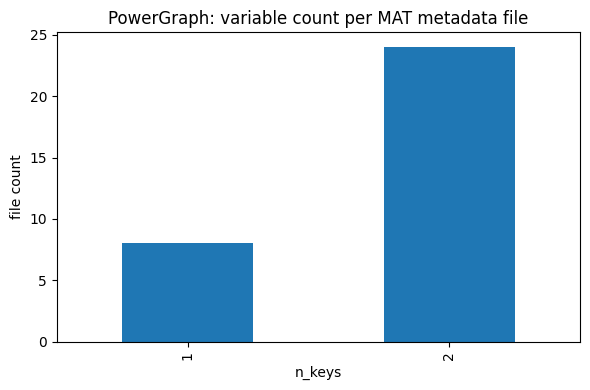

In [8]:

plt.figure(figsize=(6,4))
pg_df['n_keys'].value_counts().sort_index().plot(kind='bar')
plt.title('PowerGraph: variable count per MAT metadata file')
plt.xlabel('n_keys')
plt.ylabel('file count')
plt.tight_layout()
plt.savefig(OUT/'fig_powergraph_nkeys_bar.png', dpi=200)
plt.show()


## 3) Export paper-ready tables

In [9]:

case_df.to_csv(OUT/'tbl_opf_case_distribution.csv', index=False)
stats_df.to_csv(OUT/'tbl_opf_summary_stats.csv', index=False)
pg_df.to_csv(OUT/'tbl_powergraph_files.csv', index=False)
print('Saved:', OUT/'tbl_opf_case_distribution.csv')
print('Saved:', OUT/'tbl_opf_summary_stats.csv')
print('Saved:', OUT/'tbl_powergraph_files.csv')


Saved: tbl_opf_case_distribution.csv
Saved: tbl_opf_summary_stats.csv
Saved: tbl_powergraph_files.csv


In [10]:

con.close()
